In [1]:
# importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# data collection and exploration
dataset_url = "http://bit.ly/w-data"
dataset = pd.read_csv(dataset_url)
dataset.head(10)

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30
5,1.5,20
6,9.2,88
7,5.5,60
8,8.3,81
9,2.7,25


In [3]:
# clearing the warning of linear regression
feature_names = ['Hours']

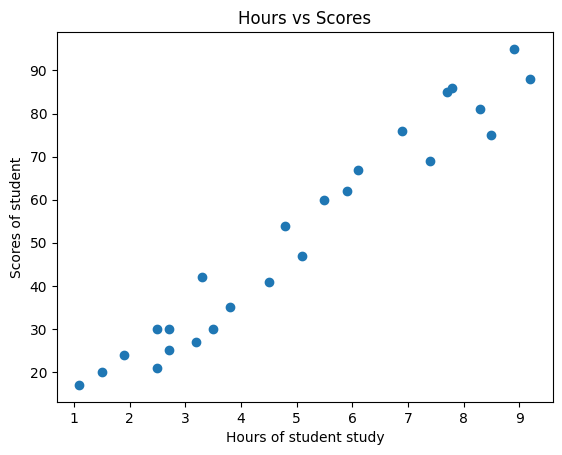

In [4]:
# data visualization
plt.scatter(dataset['Hours'],dataset['Scores'])
plt.title('Hours vs Scores')
plt.xlabel('Hours of student study')
plt.ylabel('Scores of student')
plt.show()

In [5]:
# spliting the data into training and test data
X = dataset[feature_names]
y = dataset['Scores']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [6]:
# model selection and training for 2 variables
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
# model evaluating
y_pred = model.predict(X_test)
ma_error = mean_absolute_error(y_test, y_pred)
ms_error = mean_squared_error(y_test, y_pred)
root_ms_error = np.sqrt(ms_error)

print(f"X_test prediction value is {y_pred}")
print(ma_error)
print(ms_error)
print(root_ms_error)

X_test prediction value is [16.88414476 33.73226078 75.357018   26.79480124 60.49103328]
4.183859899002975
21.598769307217406
4.647447612100367


In [8]:
# making prediction
hours_predict = 9.25
prediction_value = model.predict(np.array([[hours_predict]]))

c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [9]:
# printing the predicted scores
print(f"Predicted score for {hours_predict} hours of study: {prediction_value[0]}")

Predicted score for 9.25 hours of study: 93.69173248737535


Model Evaluation Metrics:
Mean Absolute Error (MAE): 4.183859899002975
Mean Squared Error (MSE): 21.598769307217406
Root Mean Squared Error (RMSE): 4.647447612100367
Predicted score for 9.25 hours of study: 93.69173248737535


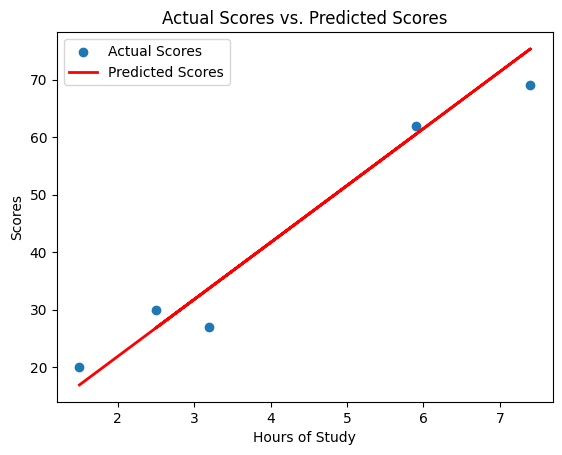

In [10]:
# summarizing the results and visualization
print("Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {ma_error}")
print(f"Mean Squared Error (MSE): {ms_error}")
print(f"Root Mean Squared Error (RMSE): {root_ms_error}")
print(f"Predicted score for {hours_predict} hours of study: {prediction_value[0]}")
# Visualization of Predictions vs. Actual Data
plt.scatter(X_test, y_test, label='Actual Scores')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Scores')
plt.xlabel('Hours of Study')
plt.ylabel('Scores')
plt.title('Actual Scores vs. Predicted Scores')
plt.legend()
plt.show()